In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_id='1CYrxYdLOlHOar8PhTo4rVps2vM06yTkQ'
url= f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [3]:
df_copy=df.copy()

In [4]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [5]:
#chcek missing in each column
df_copy.isnull().sum()[df_copy.isnull().sum() != 0].sort_values(ascending=False)

,0


In [6]:
#check duplicates
duplicates = df_copy.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [7]:
#add some def columns
df_copy["Month_name"] = pd.to_datetime(df["Month"], format="%m").dt.month_name()
weekend_days = ["Saturday", "Sunday"]
df_copy["day_type"] = df_copy["Weekday Name"].isin(weekend_days).map({True:"Weekend", False:"Working Day"})

In [8]:
df_copy

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,Month_name,day_type
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday,January,Working Day
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday,January,Working Day
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday,January,Weekend
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday,January,Weekend
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday,January,Working Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday,October,Working Day
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday,October,Weekend
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday,October,Weekend
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday,October,Working Day


In [85]:
#remove unnesscary column
df_copy=df_copy.drop("Hour", axis='columns')
df_copy

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Month_name,Weekday Name,day_type
0,1/2/2014,0.0,4.0,3.0,32.0,7.0,0.0,0.0,2.0,2014,1,January,Thursday,Working Day
1,1/3/2014,8.0,4.0,4.0,51.0,16.0,0.0,20.0,4.0,2014,1,January,Friday,Working Day
2,1/4/2014,2.0,1.0,6.0,62.0,10.0,0.0,9.0,1.0,2014,1,January,Saturday,Weekend
3,1/5/2014,4.0,3.0,7.0,41.0,8.0,0.0,3.0,0.0,2014,1,January,Sunday,Weekend
4,1/6/2014,5.0,1.0,4.0,22.0,16.0,2.0,6.0,2.0,2014,1,January,Monday,Working Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.0,6.0,2.0,22.0,13.0,0.0,1.0,1.0,2019,10,October,Friday,Working Day
2102,10/5/2019,4.0,5.0,6.0,25.0,7.0,0.0,0.0,0.0,2019,10,October,Saturday,Weekend
2103,10/6/2019,4.0,12.0,2.0,35.0,6.0,0.0,5.0,4.0,2019,10,October,Sunday,Weekend
2104,10/7/2019,7.0,5.0,3.0,51.0,6.0,0.0,10.0,1.0,2019,10,October,Monday,Working Day


In [9]:
#reorder the table
df_copy = df_copy.loc[:, "datum":"R06"].join(df_copy[["Year","Month","Month_name","Weekday Name","day_type","Hour"]])

In [10]:
df_copy

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Month_name,Weekday Name,day_type,Hour
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,January,Thursday,Working Day,248
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,January,Friday,Working Day,276
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,January,Saturday,Weekend,276
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,January,Sunday,Weekend,276
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,January,Monday,Working Day,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,October,Friday,Working Day,276
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,October,Saturday,Weekend,276
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,October,Sunday,Weekend,276
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,October,Monday,Working Day,276


In [27]:
#Rounding sales to a whole number
df_copy.loc[:, "M01AB":"R06"] = df_copy.loc[:, "M01AB":"R06"].round()
df_copy

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Month_name,Weekday Name,day_type,Hour
0,1/2/2014,0.0,4.0,3.0,32.0,7.0,0.0,0.0,2.0,2014,1,January,Thursday,Working Day,248
1,1/3/2014,8.0,4.0,4.0,51.0,16.0,0.0,20.0,4.0,2014,1,January,Friday,Working Day,276
2,1/4/2014,2.0,1.0,6.0,62.0,10.0,0.0,9.0,1.0,2014,1,January,Saturday,Weekend,276
3,1/5/2014,4.0,3.0,7.0,41.0,8.0,0.0,3.0,0.0,2014,1,January,Sunday,Weekend,276
4,1/6/2014,5.0,1.0,4.0,22.0,16.0,2.0,6.0,2.0,2014,1,January,Monday,Working Day,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.0,6.0,2.0,22.0,13.0,0.0,1.0,1.0,2019,10,October,Friday,Working Day,276
2102,10/5/2019,4.0,5.0,6.0,25.0,7.0,0.0,0.0,0.0,2019,10,October,Saturday,Weekend,276
2103,10/6/2019,4.0,12.0,2.0,35.0,6.0,0.0,5.0,4.0,2019,10,October,Sunday,Weekend,276
2104,10/7/2019,7.0,5.0,3.0,51.0,6.0,0.0,10.0,1.0,2019,10,October,Monday,Working Day,276


In [30]:
#total sales quantities for each drug category (ATC code)
total_sales=df_copy.loc[:, "M01AB":"R06"].sum()
total_sales

,0
M01AB,10454.0
M01AE,8140.0
N02BA,8103.0
N02BE,62952.0
N05B,18646.0
N05C,1248.0
R03,11607.0
R06,6074.0


In [35]:
#drug brands that have the highest total sales
total_sales.idxmax(), total_sales.max()

('N02BE', 62952.0)

In [56]:
# three drugs that have the highest sales in January 2015
df_jan=df_copy[(df_copy["Year"] == 2015) & (df_copy["Month"] == 1)]
df_jan.loc[:, "M01AB":"R06"].sum().head(3).sort_values(ascending=False)


,0
N02BA,141.0
M01AB,134.0
M01AE,128.0


In [55]:
# three drugs that have the highest sales in July 2016
df_jul=df_copy[(df_copy["Year"] == 2016) & (df_copy["Month"] == 7)]
df_jul.loc[:, "M01AB":"R06"].sum().head(3).sort_values(ascending=False)


,0
M01AB,192.0
M01AE,140.0
N02BA,136.0


In [54]:
# three drugs that have the highest sales in September 2017
df_sep=df_copy[(df_copy["Year"] == 2017) & (df_copy["Month"] == 9)]
df_sep.loc[:, "M01AB":"R06"].sum().head(3).sort_values(ascending=False)


,0
M01AB,136.0
M01AE,116.0
N02BA,86.0


In [62]:
#drug that has sold the most often in 2017
df_17=df_copy[(df_copy["Year"] == 2017)]
sum_17=df_17.loc[:, "M01AB":"R06"].sum()
sum_17.idxmax(), sum_17.max()

('N02BE', 9250.0)

In [77]:
#drug category that has the highest average daily sales
average_daily_sales = df_copy.loc[:, "M01AB":"R06"].mean()
average_daily_sales.idxmax(), round(average_daily_sales.max(),2)

('N02BE', 29.89)

In [92]:
#Are respiratory drugs (R03) sold more during specific months?
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df_copy["Month_name"] = pd.Categorical(df_copy["Month_name"], categories=month_order, ordered=True)

monthly_sales = df_copy.groupby("Month_name")["R03"].sum()
monthly_sales


/tmp/ipykernel_1298/2165017492.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df_copy.groupby("Month_name")["R03"].sum()


,R03
Month_name,
January,1264.0
February,1165.0
March,1170.0
April,1039.0
May,931.0
June,783.0
July,550.0
August,577.0
September,792.0


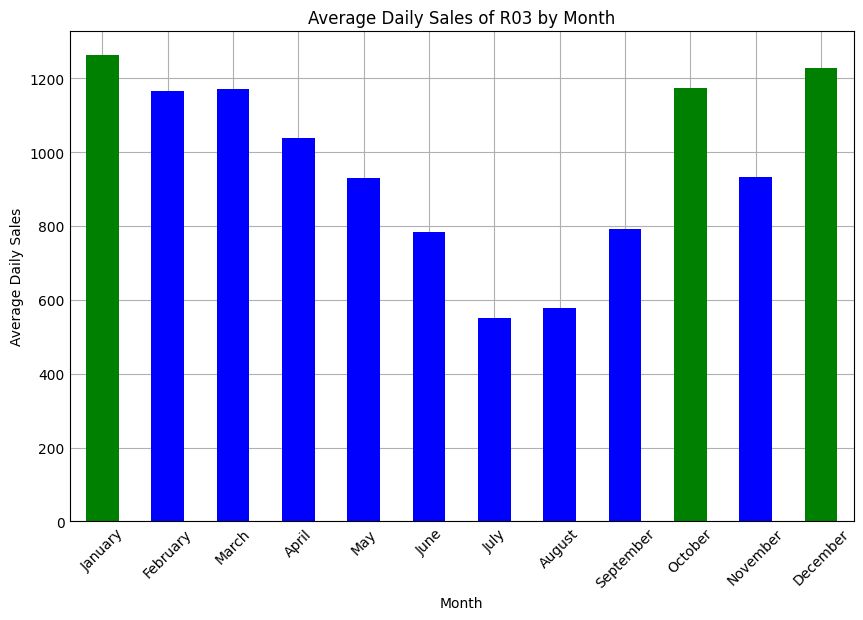

In [100]:
top_month = monthly_sales.nlargest(3).index
colors = ["blue" if month not in top_month else "green" for month in monthly_sales.index]

monthly_sales.plot(kind="bar", figsize=(8,5), color=colors)
plt.title("Average Daily Sales of R03 by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.show()